In [1]:
import pandas as pd
import geopandas as gpd
import os

dataset_folder = r"C:\Users\michael\Desktop\IDX Exchange\Files\datasets"
os.chdir(dataset_folder)

In [2]:
df_sold = pd.read_csv("CRMLSSold_3.csv", low_memory = False)
df_listings = pd.read_csv("CRMLSListing_3.csv", low_memory = False)

In [3]:
df_sold.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,OriginatingSystemName,OriginatingSystemSubName,year_month,rate_30yr_fixed
0,ContraCosta,ContraCosta,"Tile,Wood",NaN,False,5000000.0,1095075487,2024-01-18,5000000.0,Erin,...,False,3.0,NaN,94595,NaN,30240.0,CRMLS,CRMLS_CCBE,2024-01,6.6425
1,NaN,Mlslistings,NaN,False,NaN,NaN,1079166779,2024-01-30,858000.0,David,...,False,2.0,Palm Springs Unified,92262,NaN,13504.0,CRMLS,CRMLS_MLSL,2024-01,6.6425
2,Glendale,Southland,NaN,False,False,1890500.0,1075037759,2024-01-29,1890500.0,Karen,...,False,2.0,Los Angeles Unified,91356,0.0,17873.0,CRMLS,CRMLS_CRM,2024-01,6.6425
3,NorthSanLuisObispo,NorthSanLuisObispo,NaN,True,False,2100000.0,1067652762,2024-01-02,2100000.0,Jennifer,...,False,3.0,San Luis Coastal Unified,93401,0.0,11219.0,CRMLS,CRMLS_CRM,2024-01,6.6425
4,CoastalMendocino,CoastalMendocino,Tile,True,False,1950000.0,1063453216,2024-01-22,1950000.0,Kira,...,NaN,2.0,NaN,95437,NaN,74487.6,CRMLS,CRMLS_CRF,2024-01,6.6425


In [4]:
df_listings.head()

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,...,NewConstructionYN,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,UnparsedAddress.1,year_month,rate_30yr_fixed
0,759000.0,1159972295,NaN,NaN,Richard,Sirois,33.738910,-116.198447,42680 Incantata Place,Residential,...,False,2.0,Desert Sands Unified,92203,NaN,289.0,5227.0,42680 Incantata Place,2024-01,6.6425
1,320000.0,1159871345,2026-05-11,320000.0,Nicholas,Miller,33.842793,-116.481803,28388 Desert Princess Drive,Residential,...,False,1.0,NaN,92234,Coldwell Banker Realty,855.0,1307.0,28388 Desert Princess Drive,2024-01,6.6425
2,115900.0,1153320466,2026-04-10,160000.0,Heidi,Dunk-Vincent,39.125903,-122.861472,6900 Glenn,Residential,...,False,1.0,Upper Lake Union,95464,Noble Realty,0.0,3920.0,6900 Glenn,2024-01,6.6425
3,2500000.0,1146529264,2026-04-17,2000000.0,Clifford,Stevens,34.150964,-118.390267,4415 Morella Ave,Residential,...,False,2.0,Los Angeles Unified,91607,Equity Union,0.0,9906.0,4415 Morella Ave,2024-01,6.6425
4,3200000.0,1118382573,2025-05-21,3200000.0,Trudy,McGrath,33.028788,-117.264434,1200 Cardiff Drive,Residential,...,False,0.0,San Dieguito Union,92024,NonMember/Member-Other Board,0.0,54885.6,1200 Cardiff Drive,2024-01,6.6425


In [5]:
df_sold_original_rows = len(df_sold)
df_listings_original_rows = len(df_listings)

print("Row Counts (BEFORE):")
print(f"- Sold: {len(df_sold)}")
print(f"- Listings: {len(df_listings)}")

Row Counts (BEFORE):
- Sold: 455658
- Listings: 504466


In [6]:
sold_original_dtypes = sorted(df_sold.dtypes.unique().astype(str).tolist())
listings_original_dtypes = sorted(df_listings.dtypes.unique().astype(str).tolist())

print("Data Type Confirmations (BEFORE):")
print(f"- Sold: {sold_original_dtypes}")
print(f"- Listings: {listings_original_dtypes}")

Data Type Confirmations (BEFORE):
- Sold: ['float64', 'int64', 'object']
- Listings: ['float64', 'int64', 'object']


In [32]:
# Fields transformed from strings to datetime format, allowing for reliable datetime-based analysis.
date_fields = ["CloseDate", "PurchaseContractDate", "ListingContractDate", "ContractStatusChangeDate"]

for field in date_fields:
    df_sold[field] = pd.to_datetime(df_sold[field])
    df_listings[field] = pd.to_datetime(df_listings[field])
    print(f"{field} (Sold): {df_sold[field].dtype}")
    print(f"{field} (Listings): {df_listings[field].dtype}\n")

CloseDate (Sold): datetime64[ns]
CloseDate (Listings): datetime64[ns]

PurchaseContractDate (Sold): datetime64[ns]
PurchaseContractDate (Listings): datetime64[ns]

ListingContractDate (Sold): datetime64[ns]
ListingContractDate (Listings): datetime64[ns]

ContractStatusChangeDate (Sold): datetime64[ns]
ContractStatusChangeDate (Listings): datetime64[ns]



In [8]:
# No numeric fields were modified, all were properly typed as either "float64" or "int64"
numeric_fields = ["OriginalListPrice", "ClosePrice", "Latitude", "Longitude", "LivingArea", "ListPrice", "DaysOnMarket", "ListingKeyNumeric", "ParkingTotal", "LotSizeAcres", "YearBuilt", "StreetNumberNumeric", "BathroomsTotalInteger", "BedroomsTotal", "Stories", "LotSizeArea", "MainLevelBedrooms", "GarageSpaces", "AssociationFee", "LotSizeSquareFeet", "rate_30yr_fixed"]

print("Sold:")
for field in numeric_fields:
    print(f"- {field}: {df_sold[field].dtype}")

print("\nListings:")
for field in numeric_fields:
    print(f"- {field}: {df_listings[field].dtype}")

Sold:
- OriginalListPrice: float64
- ClosePrice: float64
- Latitude: float64
- Longitude: float64
- LivingArea: float64
- ListPrice: float64
- DaysOnMarket: int64
- ListingKeyNumeric: int64
- ParkingTotal: float64
- LotSizeAcres: float64
- YearBuilt: float64
- StreetNumberNumeric: float64
- BathroomsTotalInteger: float64
- BedroomsTotal: float64
- Stories: float64
- LotSizeArea: float64
- MainLevelBedrooms: float64
- GarageSpaces: float64
- AssociationFee: float64
- LotSizeSquareFeet: float64
- rate_30yr_fixed: float64

Listings:
- OriginalListPrice: float64
- ClosePrice: float64
- Latitude: float64
- Longitude: float64
- LivingArea: float64
- ListPrice: float64
- DaysOnMarket: int64
- ListingKeyNumeric: int64
- ParkingTotal: float64
- LotSizeAcres: float64
- YearBuilt: float64
- StreetNumberNumeric: float64
- BathroomsTotalInteger: float64
- BedroomsTotal: float64
- Stories: float64
- LotSizeArea: float64
- MainLevelBedrooms: float64
- GarageSpaces: float64
- AssociationFee: float64
-

In [9]:
# The following is used as reference for identifying out-of-state or implausible coordinates for flagging invalid geographic data.
df_sold = gpd.GeoDataFrame(df_sold, 
                           geometry = gpd.points_from_xy(df_sold["Longitude"], df_sold["Latitude"]), 
                           crs = "EPSG:4326")

df_listings = gpd.GeoDataFrame(df_listings, 
                               geometry = gpd.points_from_xy(df_listings["Longitude"], df_listings["Latitude"]), 
                               crs = "EPSG:4326")

# GeoJSON of California's borders was retrieved from "https://gis.data.ca.gov/api/download/v1/items/ca7b47512a2a442fbfa039bded0b6eaf/geojson?layers=0", place this file in the "datasets" folder
gdf_california_borders = gpd.read_file("State_Boundary_-2054994179663043177.geojson")
gdf_california_borders = gdf_california_borders.to_crs("EPSG:4326")
california_borders = gdf_california_borders.geometry.iloc[0]

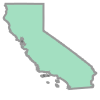

In [10]:
california_borders

In [11]:
df_sold_flagged = df_sold.copy()
df_listings_flagged = df_listings.copy()

In [12]:
# The following flags mark records with invalid numeric values:
def flag_invalid_numeric_values(df_flagged):
    # ClosePrice <= 0
    df_flagged["non_positive_close_price_flag"] = 0
    df_flagged.loc[(df_flagged.ClosePrice <= 0), "non_positive_close_price_flag"] = 1

    # LivingArea <= 0
    df_flagged["non_positive_living_area_flag"] = 0
    df_flagged.loc[(df_flagged.LivingArea <= 0), "non_positive_living_area_flag"] = 1

    # DaysOnMarket < 0
    df_flagged["negative_days_on_market_flag"] = 0
    df_flagged.loc[(df_flagged.DaysOnMarket < 0), "negative_days_on_market_flag"] = 1

    # Negative Bedrooms or Bathrooms
    df_flagged["negative_bedrooms_flag"] = 0
    df_flagged.loc[(df_flagged.BedroomsTotal < 0), "negative_bedrooms_flag"] = 1

    df_flagged["negative_bathrooms_flag"] = 0
    df_flagged.loc[(df_flagged.BathroomsTotalInteger < 0), "negative_bathrooms_flag"] = 1

In [13]:
# ListingContractDate should precede PurchaseContractDate, which should precede CloseDate. The following flags mark records that violate these rules:
def flag_date_consistency(df_flagged):
    # ListingContractDate AFTER PurchaseContractDate
    df_flagged["listing_after_close_flag"] = 0
    df_flagged.loc[(df_flagged.ListingContractDate > df_flagged.CloseDate), "listing_after_close_flag"] = 1

    # PurchaseContractDate AFTER CloseDate
    df_flagged["purchase_after_close_flag"] = 0
    df_flagged.loc[(df_flagged.PurchaseContractDate > df_flagged.CloseDate), "purchase_after_close_flag"] = 1

    # ListingContractDate AFTER PurchaseContractDate AFTER CloseDate
    df_flagged["negative_timeline_flag"] = 0
    df_flagged.loc[(df_flagged.ListingContractDate > df_flagged.PurchaseContractDate) & (df_flagged.PurchaseContractDate > df_flagged.CloseDate), "negative_timeline_flag"] = 1

In [14]:
# The following flags mark records that have invalid geographic data:
def flag_geographic_data(df_flagged):
    # Missing coordinates (Latitude or Longitude is null)
    df_flagged["null_coords_flag"] = 0
    df_flagged.loc[(df_flagged.Latitude.isna() == True) | (df_flagged.Longitude.isna() == True), "null_coords_flag"] = 1

    # Latitude = 0 or Longitude = 0 (sentinel null values)
    df_flagged["sentinel_null_coords_flag"] = 0
    df_flagged.loc[(df_flagged.Latitude == 0) | (df_flagged.Longitude == 0), "sentinel_null_coords_flag"] = 1

    # Longitude > 0 errors (California coordinates should be negative)
    df_flagged["positive_longitude_flag"] = 0
    df_flagged.loc[(df_flagged.Longitude > 0), "positive_longitude_flag"] = 1

    # Out-of-state or implausible coordinates
    df_flagged["out_of_state_coords_flag"] = 0
    df_flagged.loc[(~df_flagged.geometry.within(california_borders)) & (df_flagged.Latitude.isna() == False) & (df_flagged.Longitude.isna() == False), "out_of_state_coords_flag"] = 1

In [15]:
flag_invalid_numeric_values(df_sold_flagged)
flag_invalid_numeric_values(df_listings_flagged)

flag_date_consistency(df_sold_flagged)
flag_date_consistency(df_listings_flagged)

flag_geographic_data(df_sold_flagged)
flag_geographic_data(df_listings_flagged)

In [16]:
df_sold_flagged.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,...,negative_days_on_market_flag,negative_bedrooms_flag,negative_bathrooms_flag,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,null_coords_flag,sentinel_null_coords_flag,positive_longitude_flag,out_of_state_coords_flag
0,ContraCosta,ContraCosta,"Tile,Wood",NaN,False,5000000.0,1095075487,2024-01-18,5000000.0,Erin,...,0,0,0,0,0,0,0,0,0,0
1,NaN,Mlslistings,NaN,False,NaN,NaN,1079166779,2024-01-30,858000.0,David,...,0,0,0,0,0,0,0,0,0,0
2,Glendale,Southland,NaN,False,False,1890500.0,1075037759,2024-01-29,1890500.0,Karen,...,0,0,0,0,0,0,0,0,0,0
3,NorthSanLuisObispo,NorthSanLuisObispo,NaN,True,False,2100000.0,1067652762,2024-01-02,2100000.0,Jennifer,...,0,0,0,0,0,0,0,0,0,0
4,CoastalMendocino,CoastalMendocino,Tile,True,False,1950000.0,1063453216,2024-01-22,1950000.0,Kira,...,1,0,0,0,0,0,0,0,0,0


In [17]:
df_listings_flagged.head()

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,...,negative_days_on_market_flag,negative_bedrooms_flag,negative_bathrooms_flag,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,null_coords_flag,sentinel_null_coords_flag,positive_longitude_flag,out_of_state_coords_flag
0,759000.0,1159972295,NaT,NaN,Richard,Sirois,33.738910,-116.198447,42680 Incantata Place,Residential,...,0,0,0,0,0,0,0,0,0,0
1,320000.0,1159871345,2026-05-11,320000.0,Nicholas,Miller,33.842793,-116.481803,28388 Desert Princess Drive,Residential,...,0,0,0,0,0,0,0,0,0,0
2,115900.0,1153320466,2026-04-10,160000.0,Heidi,Dunk-Vincent,39.125903,-122.861472,6900 Glenn,Residential,...,0,0,0,0,0,0,0,0,0,0
3,2500000.0,1146529264,2026-04-17,2000000.0,Clifford,Stevens,34.150964,-118.390267,4415 Morella Ave,Residential,...,0,0,0,0,0,0,0,0,0,0
4,3200000.0,1118382573,2025-05-21,3200000.0,Trudy,McGrath,33.028788,-117.264434,1200 Cardiff Drive,Residential,...,0,0,0,0,0,0,0,0,0,0


In [18]:
numeric_flags = ["non_positive_close_price_flag", "non_positive_living_area_flag", "negative_days_on_market_flag", "negative_bedrooms_flag", "negative_bathrooms_flag"]
date_flags = ["listing_after_close_flag", "purchase_after_close_flag", "negative_timeline_flag"]
geo_flags = ["null_coords_flag", "sentinel_null_coords_flag", "positive_longitude_flag", "out_of_state_coords_flag"]

In [19]:
df_sold_numeric_flags = df_sold_flagged[numeric_flags].agg(["sum"]).rename({"sum":"count (Sold)"}).transpose()
df_listings_numeric_flags = df_listings_flagged[numeric_flags].agg(["sum"]).rename({"sum":"count (Listings)"}).transpose()

df_numeric_flags = df_sold_numeric_flags.join(df_listings_numeric_flags)
df_numeric_flags

,count (Sold),count (Listings)
non_positive_close_price_flag,0,0
non_positive_living_area_flag,161,261
negative_days_on_market_flag,48,43
negative_bedrooms_flag,0,0
negative_bathrooms_flag,0,0


In [20]:
df_sold_date_flags = df_sold_flagged[date_flags].agg(["sum"]).rename({"sum":"count (Sold)"}).transpose()
df_listings_date_flags = df_listings_flagged[date_flags].agg(["sum"]).rename({"sum":"count (Listings)"}).transpose()

df_date_flags = df_sold_date_flags.join(df_listings_date_flags)
df_date_flags

,count (Sold),count (Listings)
listing_after_close_flag,81,82
purchase_after_close_flag,92,94
negative_timeline_flag,1,1


In [21]:
df_sold_geo_flags = df_sold_flagged[geo_flags].agg(["sum"]).rename({"sum":"count (Sold)"}).transpose()
df_listings_geo_flags = df_listings_flagged[geo_flags].agg(["sum"]).rename({"sum":"count (Listings)"}).transpose()

df_geo_flags = df_sold_geo_flags.join(df_listings_geo_flags)
df_geo_flags

,count (Sold),count (Listings)
null_coords_flag,53637,49467
sentinel_null_coords_flag,44,62
positive_longitude_flag,34,69
out_of_state_coords_flag,120,231


In [22]:
df_flag_counts = pd.concat([df_numeric_flags, df_date_flags, df_geo_flags])
df_flag_counts

,count (Sold),count (Listings)
non_positive_close_price_flag,0,0
non_positive_living_area_flag,161,261
negative_days_on_market_flag,48,43
negative_bedrooms_flag,0,0
negative_bathrooms_flag,0,0
listing_after_close_flag,81,82
purchase_after_close_flag,92,94
negative_timeline_flag,1,1
null_coords_flag,53637,49467
sentinel_null_coords_flag,44,62


In [23]:
# CRMLSSold records with invalid coordinates
df_sold_flagged[
    (df_sold_flagged.null_coords_flag == 1) | 
    (df_sold_flagged.sentinel_null_coords_flag == 1) | 
    (df_sold_flagged.positive_longitude_flag == 1) | 
    (df_sold_flagged.out_of_state_coords_flag == 1)]

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,...,negative_days_on_market_flag,negative_bedrooms_flag,negative_bathrooms_flag,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,null_coords_flag,sentinel_null_coords_flag,positive_longitude_flag,out_of_state_coords_flag
12,SanDiego,SanDiego,"Carpet,Tile",True,False,1080000.0,1059968375,2024-01-31,1080000.0,Trisha,...,0,0,0,0,0,0,1,0,0,0
20,SanDiego,SanDiego,NaN,False,False,2195000.0,1059827487,2024-01-30,2160000.0,Julie,...,0,0,0,1,0,0,1,0,0,0
27,ContraCosta,ContraCosta,"Carpet,Tile,Vinyl",True,False,1782500.0,1059614357,2024-01-31,1782500.0,Joujou,...,0,0,0,0,0,0,1,0,0,0
30,SanDiego,SanDiego,NaN,False,False,820650.0,1059608655,2024-01-30,820650.0,Nate,...,0,0,0,0,0,0,1,0,0,0
31,Mlslistings,Mlslistings,NaN,False,NaN,NaN,1059600590,2024-01-31,3500000.0,Michele Formico,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
455426,Mlslistings,Oakland,"Carpet,Tile,Vinyl",NaN,False,649000.0,1127492042,2026-06-10,599000.0,Garrett,...,0,0,0,0,0,0,1,0,0,0
455428,NaN,BayEast,"Tile,Vinyl",NaN,False,1211443.0,1127453718,2026-06-08,1035767.0,Suzie,...,0,0,0,0,0,0,1,0,0,0
455542,Oakland,Oakland,Vinyl,NaN,False,655320.0,1117428895,2026-06-09,635000.0,Garrett,...,0,0,0,0,0,0,1,0,0,0
455627,SanDiego,SanDiego,NaN,False,False,849900.0,1107113726,2026-06-08,849900.0,Mark,...,0,0,0,0,0,0,1,0,0,0


In [24]:
# CRMLSListing records with invalid coordinates
df_listings_flagged[
    (df_listings_flagged.null_coords_flag == 1) | 
    (df_listings_flagged.sentinel_null_coords_flag == 1) | 
    (df_listings_flagged.positive_longitude_flag == 1) | 
    (df_listings_flagged.out_of_state_coords_flag == 1)]

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,...,negative_days_on_market_flag,negative_bedrooms_flag,negative_bathrooms_flag,listing_after_close_flag,purchase_after_close_flag,negative_timeline_flag,null_coords_flag,sentinel_null_coords_flag,positive_longitude_flag,out_of_state_coords_flag
69,1470000.0,1078870944,2024-07-26,1450000.0,Natalie,Erster,NaN,NaN,12201 Emelita Street,Residential,...,0,0,0,0,0,0,1,0,0,0
78,915000.0,1077391331,2024-08-09,960000.0,Jason,Stead,NaN,NaN,309 Crispen,Residential,...,0,0,0,0,0,0,1,0,0,0
82,1575000.0,1077309780,2024-07-03,1575000.0,Joseph,Nuzzolo,NaN,NaN,821 Bard Street,Residential,...,0,0,0,0,0,0,1,0,0,0
90,1725000.0,1076721510,2024-07-26,1800000.0,John,Katnik,NaN,NaN,8265 E Norfolk Avenue,Residential,...,0,0,0,0,0,0,1,0,0,0
91,765000.0,1076608563,2024-08-07,811000.0,William,White,NaN,NaN,1411 E Idahome Street,Residential,...,0,0,0,0,0,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
504292,2200000.0,1170727763,NaT,NaN,Chase,Cromwell,NaN,NaN,3023 25 Via Viejas,Residential,...,0,0,0,0,0,0,1,0,0,0
504332,879000.0,1170327323,NaT,NaN,Joe,Stoveken,NaN,NaN,7627 7629 Pine Blvd,Residential,...,0,0,0,0,0,0,1,0,0,0
504383,799000.0,1169493493,NaT,NaN,Ryan,Scheller,NaN,NaN,37765 Eagle Meadow RD,Residential,...,0,0,0,0,0,0,1,0,0,0
504402,1600000.0,1169141268,NaT,NaN,Theresa,Lee,NaN,NaN,1237 Lancashire Dr,Residential,...,0,0,0,0,0,0,1,0,0,0


In [25]:
# Fields with >90% missing values were already removed (refer to "2_structuring-validation.ipynb")
# All other columns will be kept for now, as to avoid removing columns whose information will potentially become relevant in future work
# All flagged records have been removed from the filtered datasets to ensure remaining data can be used for consistent analyses

flags = numeric_flags + date_flags + geo_flags

df_sold_filtered = df_sold_flagged[~(df_sold_flagged[flags] == 1).any(axis=1)]
df_listings_filtered = df_listings_flagged[~(df_listings_flagged[flags] == 1).any(axis=1)]

In [26]:
print("Row Counts (BEFORE):")
print(f"- Sold: {df_sold_original_rows}")
print(f"- Listings: {df_listings_original_rows}\n")

print("Row Counts (AFTER):")
print(f"- Sold: {len(df_sold_filtered)}")
print(f"- Listings: {len(df_listings_filtered)}")

Row Counts (BEFORE):
- Sold: 455658
- Listings: 504466

Row Counts (AFTER):
- Sold: 401547
- Listings: 454318


In [27]:
sold_filtered_dtypes = sorted(df_sold_filtered.dtypes.unique().astype(str).tolist())
listings_filtered_dtypes = sorted(df_listings_filtered.dtypes.unique().astype(str).tolist())

print("Data Type Confirmations (BEFORE):")
print(f"- Sold: {sold_original_dtypes}")
print(f"- Listings: {listings_original_dtypes}\n")

print("Data Type Confirmations (AFTER):")
print(f"- Sold: {sold_filtered_dtypes}")
print(f"- Listings: {listings_filtered_dtypes}")

Data Type Confirmations (BEFORE):
- Sold: ['float64', 'int64', 'object']
- Listings: ['float64', 'int64', 'object']

Data Type Confirmations (AFTER):
- Sold: ['datetime64[ns]', 'float64', 'geometry', 'int64', 'object']
- Listings: ['datetime64[ns]', 'float64', 'geometry', 'int64', 'object']


In [28]:
# Drops flag columns after flagged records have been dropped, only run this once
df_sold_filtered = df_sold_filtered.drop(columns = flags)
df_listings_filtered = df_listings_filtered.drop(columns = flags)

In [29]:
df_sold_filtered.head()

,BuyerAgentAOR,ListAgentAOR,Flooring,ViewYN,PoolPrivateYN,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,...,GarageSpaces,HighSchoolDistrict,PostalCode,AssociationFee,LotSizeSquareFeet,OriginatingSystemName,OriginatingSystemSubName,year_month,rate_30yr_fixed,geometry
0,ContraCosta,ContraCosta,"Tile,Wood",NaN,False,5000000.0,1095075487,2024-01-18,5000000.0,Erin,...,3.0,NaN,94595,NaN,30240.0,CRMLS,CRMLS_CCBE,2024-01,6.6425,POINT (-122.08132 37.88531)
1,NaN,Mlslistings,NaN,False,NaN,NaN,1079166779,2024-01-30,858000.0,David,...,2.0,Palm Springs Unified,92262,NaN,13504.0,CRMLS,CRMLS_MLSL,2024-01,6.6425,POINT (-116.54054 33.84983)
2,Glendale,Southland,NaN,False,False,1890500.0,1075037759,2024-01-29,1890500.0,Karen,...,2.0,Los Angeles Unified,91356,0.0,17873.0,CRMLS,CRMLS_CRM,2024-01,6.6425,POINT (-118.55875 34.16438)
3,NorthSanLuisObispo,NorthSanLuisObispo,NaN,True,False,2100000.0,1067652762,2024-01-02,2100000.0,Jennifer,...,3.0,San Luis Coastal Unified,93401,0.0,11219.0,CRMLS,CRMLS_CRM,2024-01,6.6425,POINT (-120.64679 35.2772)
5,Mlslistings,Mlslistings,"Tile,Wood",True,NaN,NaN,1061988701,2024-01-31,2340000.0,Danny,...,3.0,Other,95148,NaN,8712.0,CRMLS,CRMLS_MLSL,2024-01,6.6425,POINT (-121.78025 37.32545)


In [30]:
df_listings_filtered.head()

,OriginalListPrice,ListingKey,CloseDate,ClosePrice,ListAgentFirstName,ListAgentLastName,Latitude,Longitude,UnparsedAddress,PropertyType,...,GarageSpaces,HighSchoolDistrict,PostalCode,BuyerOfficeName.1,AssociationFee,LotSizeSquareFeet,UnparsedAddress.1,year_month,rate_30yr_fixed,geometry
0,759000.0,1159972295,NaT,NaN,Richard,Sirois,33.738910,-116.198447,42680 Incantata Place,Residential,...,2.0,Desert Sands Unified,92203,NaN,289.0,5227.0,42680 Incantata Place,2024-01,6.6425,POINT (-116.19845 33.73891)
1,320000.0,1159871345,2026-05-11,320000.0,Nicholas,Miller,33.842793,-116.481803,28388 Desert Princess Drive,Residential,...,1.0,NaN,92234,Coldwell Banker Realty,855.0,1307.0,28388 Desert Princess Drive,2024-01,6.6425,POINT (-116.4818 33.84279)
2,115900.0,1153320466,2026-04-10,160000.0,Heidi,Dunk-Vincent,39.125903,-122.861472,6900 Glenn,Residential,...,1.0,Upper Lake Union,95464,Noble Realty,0.0,3920.0,6900 Glenn,2024-01,6.6425,POINT (-122.86147 39.1259)
3,2500000.0,1146529264,2026-04-17,2000000.0,Clifford,Stevens,34.150964,-118.390267,4415 Morella Ave,Residential,...,2.0,Los Angeles Unified,91607,Equity Union,0.0,9906.0,4415 Morella Ave,2024-01,6.6425,POINT (-118.39027 34.15096)
4,3200000.0,1118382573,2025-05-21,3200000.0,Trudy,McGrath,33.028788,-117.264434,1200 Cardiff Drive,Residential,...,0.0,San Dieguito Union,92024,NonMember/Member-Other Board,0.0,54885.6,1200 Cardiff Drive,2024-01,6.6425,POINT (-117.26443 33.02879)


In [35]:
# Save datasets as CSVs
df_sold_filtered.to_csv("CRMLSSold_4.csv", index = False)
df_listings_filtered.to_csv("CRMLSListing_4.csv", index = False)